In [53]:
import numpy as np 
import rebound
import os
import matplotlib.pyplot as plt
import dill
import pandas as pd

In [54]:
tess_offset =  2457000

In [55]:
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    # print(f'tau: {tau[0]}') 
    # print(f'omega: {omega[0]}')
    # print(f'e: {e[0]}')
    # print(f'Tc: {Tc[0]}')
    # print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


# Data

In [56]:
### get the posterior data
extension = '_8_chain'
file_name = f'simulation_master{extension}.csv'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(working_dir, file_name)

In [57]:
df_master = pd.read_csv(file_path)
print(df_master)

   draw_index  stable            note       m_b     a_b    e_b     inc_b  \
0        1414   False  orbit crossing  0.000337  0.0804  0.031  1.537635   
1        2194   False  orbit crossing  0.000337  0.0804  0.031  1.537635   

   Omega_b   omega_b       M_b  ...   omega_d       M_d       m_e    a_e  \
0      0.0  0.087266  2.523679  ... -2.444584  1.429351  0.000343  0.407   
1      0.0  0.087266  2.523679  ... -2.909138  2.005462  0.000343  0.407   

     e_e     inc_e  Omega_e   omega_e       M_e  \
0  0.031  1.570796      0.0 -2.268928  4.014126   
1  0.031  1.570796      0.0 -2.268928  4.014126   

                        detail_file  
0  sim_details_8_chain/sim_1414.csv  
1  sim_details_8_chain/sim_2194.csv  

[2 rows x 32 columns]


In [58]:
detail_files = df_master['detail_file']
print(detail_files)

0    sim_details_8_chain/sim_1414.csv
1    sim_details_8_chain/sim_2194.csv
Name: detail_file, dtype: object


In [59]:
# for i in range(len(detail_files)):
#     file = detail_files[i]
#     file_path = os.path.join(working_dir, file)
#     df_sim = pd.read_csv(file_path)
#     times = df_sim['time_days']
#     x_p1 = df_sim['x_p1']
#     z_p1 = df_sim['z_p1']
#     e_p1 = df_sim['e_p1']
    


In [60]:
stable = df_master['stable']
stable_count = sum(stable)
total = len(stable)
stable_fraction = stable_count / total
print(f"Fraction of stable posterior draws: {stable_fraction:.2f}")
print(f"{stable_count} stable of {total} total systems")
print(df_master['note'])

Fraction of stable posterior draws: 0.00
0 stable of 2 total systems
0    orbit crossing
1    orbit crossing
Name: note, dtype: object


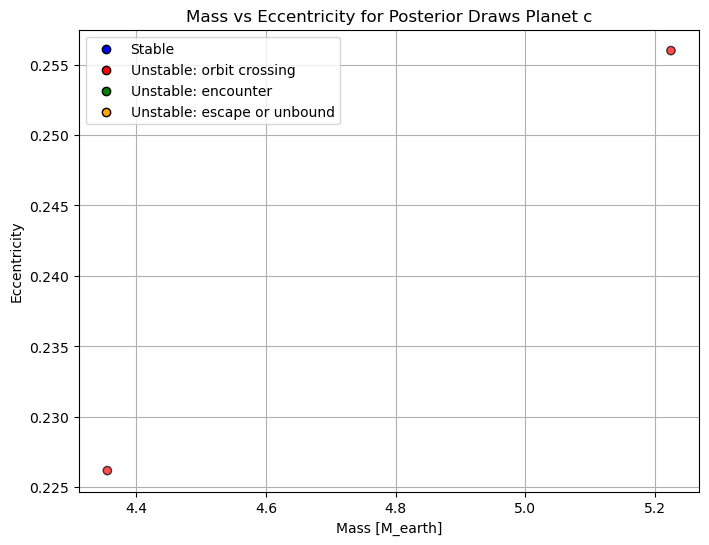

In [61]:
color_list = []
m_planet = df_master['m_c']
from astropy.constants import M_earth, M_sun
m_earth = m_planet / (M_earth / M_sun)
e_planet = df_master['e_c']
draw_idx = df_master['draw_index']
notes = df_master['note']
for i in range(len(df_master)):
    note = notes[i]
    if stable[i]:
        color_list.append('blue')
    elif note =='orbit crossing':
        color_list.append('red')
    elif note=='encounter':
        color_list.append('green')
    elif note=='escape or unbound':
        color_list.append('orange')
    else:
        color_list.append('black')

    
# Now plot all draws
plt.figure(figsize=(8,6))
plt.scatter(m_earth, e_planet, c=color_list, edgecolor='k', alpha=0.7)
# Add dummy points for legend
plt.scatter([], [], c='blue', edgecolor='k', label='Stable')
plt.scatter([], [], c='red', edgecolor='k', label='Unstable: orbit crossing')
plt.scatter([], [], c='green', edgecolor='k', label='Unstable: encounter')
plt.scatter([], [], c='orange', edgecolor='k', label='Unstable: escape or unbound')

plt.xlabel("Mass [M_earth]")  # adjust units to match your data
plt.ylabel("Eccentricity")
plt.title("Mass vs Eccentricity for Posterior Draws Planet c")
plt.legend()
plt.grid(True)
plt.show()

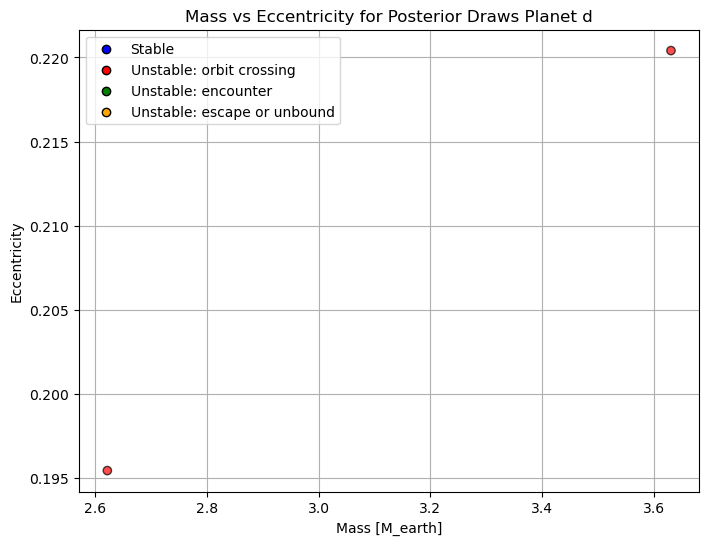

In [62]:
color_list = []
m_planet = df_master['m_d']
from astropy.constants import M_earth, M_sun
m_earth = m_planet / (M_earth / M_sun)
e_planet = df_master['e_d']
draw_idx = df_master['draw_index']
notes = df_master['note']

for i in range(len(df_master)):
    note = notes[i]
    if stable[i]:
        color_list.append('blue')
    elif note =='orbit crossing':
        color_list.append('red')
    elif note=='encounter':
        color_list.append('green')
    elif note=='escape or unbound':
        color_list.append('orange')
    else:
        color_list.append('black')

    
# Now plot all draws
plt.figure(figsize=(8,6))
plt.scatter(m_earth, e_planet, c=color_list, edgecolor='k', alpha=0.7)
# Add dummy points for legend
plt.scatter([], [], c='blue', edgecolor='k', label='Stable')
plt.scatter([], [], c='red', edgecolor='k', label='Unstable: orbit crossing')
plt.scatter([], [], c='green', edgecolor='k', label='Unstable: encounter')
plt.scatter([], [], c='orange', edgecolor='k', label='Unstable: escape or unbound')


plt.xlabel("Mass [M_earth]")  # adjust units to match your data
plt.ylabel("Eccentricity")
plt.title("Mass vs Eccentricity for Posterior Draws Planet d")
plt.legend()
plt.grid(True)
plt.show()

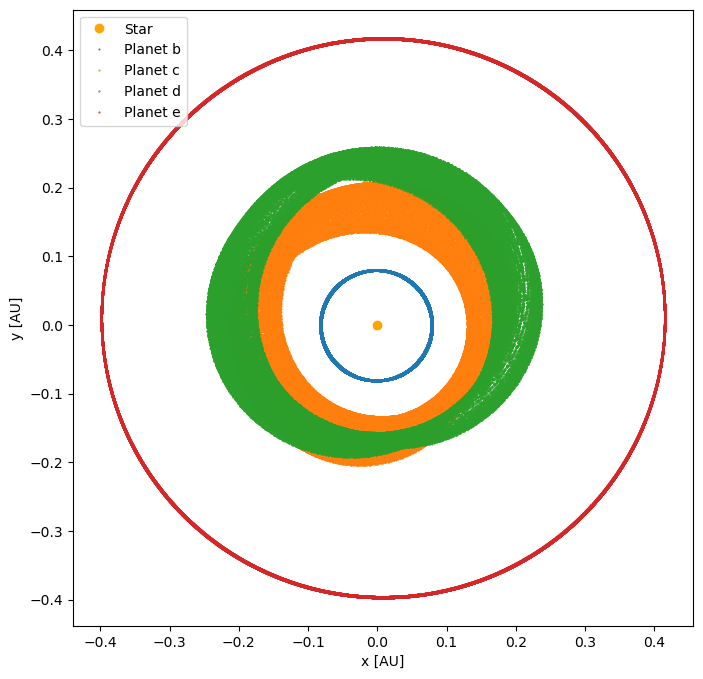

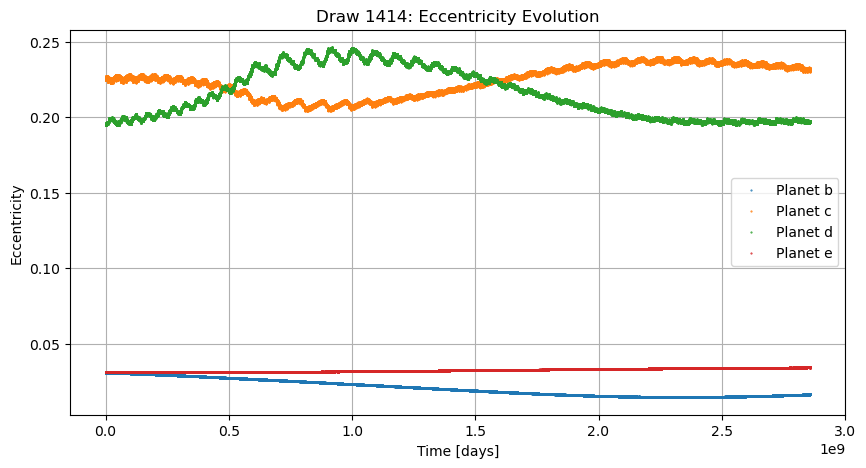

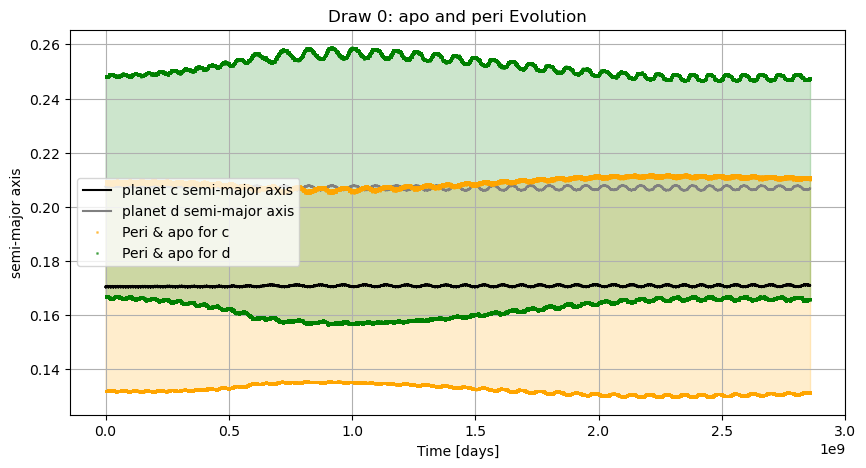

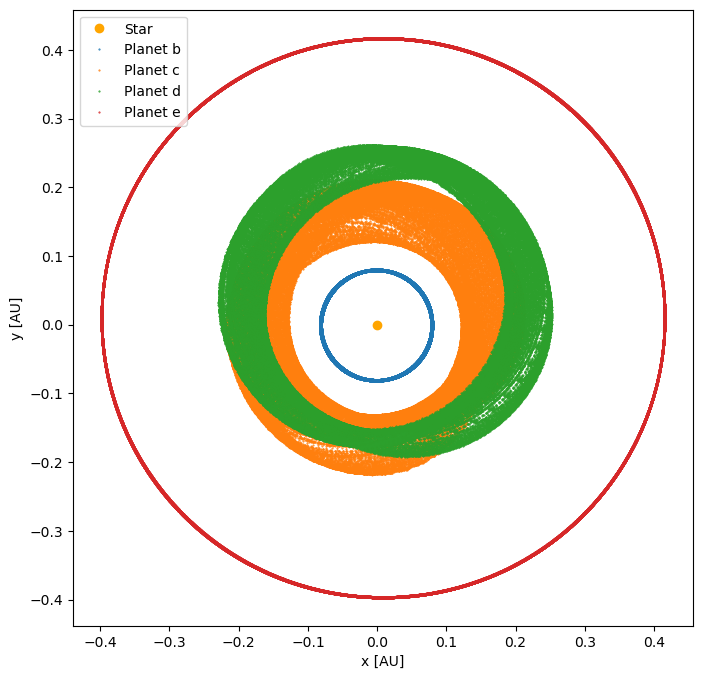

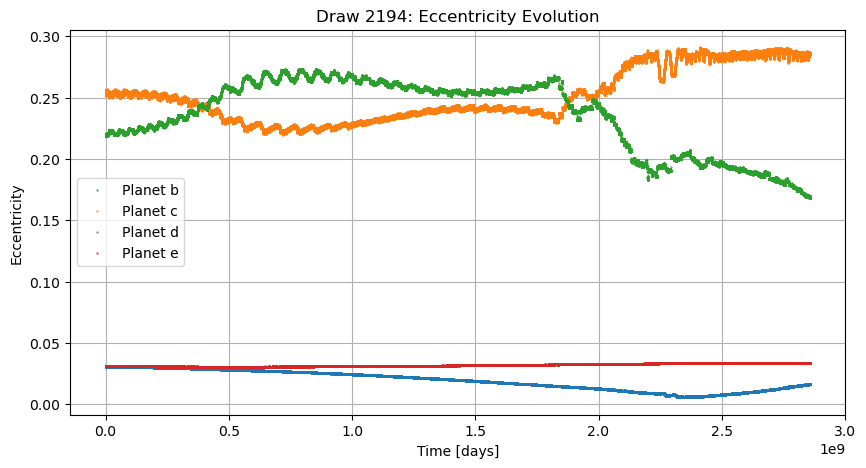

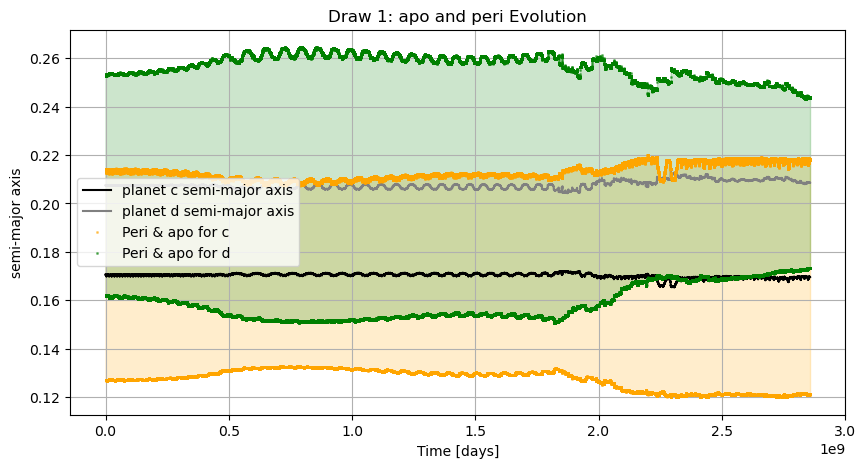

In [63]:
indices = range(0,5)
indices= [0,1]
df = df_master[df_master['note']=='stable'].reset_index(drop=True)
df = df_master
# print(df)
for i in indices:
    sim_detail = df['detail_file'][i]
    draw = df['draw_index'][i]
    
    file_path = os.path.join(working_dir, sim_detail)
    df_sim = pd.read_csv(file_path)
    times = df_sim['time_days']
    x_p1 = df_sim['x_p1']
    z_p1 = df_sim['z_p1']
    e_p1 = df_sim['e_p1']
    a_p1 = df_sim['a_p1']
    inc_p1 = df_sim['inc_p1']
    x_p2 = df_sim['x_p2']
    z_p2 = df_sim['z_p2']
    e_p2 = df_sim['e_p2']
    a_p2 = df_sim['a_p2']
    inc_p2 = df_sim['inc_p2']
    x_p3 = df_sim['x_p3']
    z_p3 = df_sim['z_p3']
    e_p3 = df_sim['e_p3']
    a_p3 = df_sim['a_p3']
    inc_p3 = df_sim['inc_p3']
    x_p4 = df_sim['x_p4']
    z_p4 = df_sim['z_p4']
    e_p4 = df_sim['e_p4']
    a_p4 = df_sim['a_p4']
    inc_p4 = df_sim['inc_p4']

    plt.figure(figsize = (8,8))
    plt.plot(0,0,'o', color='orange', label='Star')
    plt.plot(x_p1, z_p1, '.', markersize=1, label='Planet b')
    plt.plot(x_p2, z_p2, '.', markersize=1, label='Planet c')
    plt.plot(x_p3, z_p3, '.', markersize=1, label='Planet d')
    plt.plot(x_p4, z_p4, '.', markersize=1, label='Planet e')
    plt.xlabel('x [AU]')
    plt.ylabel('y [AU]')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.plot(times, e_p1, '.', markersize=1, label='Planet b')
    plt.plot(times, e_p2, '.', markersize=1, label='Planet c')
    plt.plot(times, e_p3, '.', markersize=1, label='Planet d')
    plt.plot(times, e_p4, '.', markersize=1, label='Planet e')
    plt.title(f'Draw {draw}: Eccentricity Evolution')
    plt.xlabel('Time [days]')
    plt.ylabel('Eccentricity')
    plt.legend()
    plt.grid(True)
    plt.show()

    # plt.figure(figsize=(10,5))
    # plt.plot(times, a_p1, '.', markersize=1, label='Planet b')
    # plt.plot(times, a_p2, '.', markersize=1, label='Planet c')
    # plt.plot(times, a_p3, '.', markersize=1, label='Planet d')
    # plt.plot(times, a_p4, '.', markersize=1, label='Planet e')
    # plt.title(f'Draw {draw}: Eccentricity Evolution')
    # plt.xlabel('Time [days]')
    # plt.ylabel('semi-major axis')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    # plot peri and apo evolution 
    peri_c = a_p2 * (1 - e_p2)
    apo_c = a_p2 * (1 + e_p2)
    peri_d = a_p3 * (1 - e_p3)
    apo_d = a_p3 * (1 + e_p3)
    

    plt.figure(figsize=(10,5))
    plt.plot(times, a_p2, color='black', label=f'planet c semi-major axis')
    plt.plot(times, a_p3, color='grey', label=f'planet d semi-major axis')
    # plt.plot(times, e[:,1], '.', markersize=1, color='orange', label=f'planet c')
    # plt.plot(times, e[:,2], '.', markersize=1, color='green', label=f'planet d')
    plt.plot(times, peri_c, 's', markersize=1, color='orange', alpha=0.5, label=f'Peri & apo for c')
    plt.plot(times, apo_c, 's', markersize=1, color='orange', alpha=0.5)#,  label=f'Apo c')
    plt.plot(times, peri_d, 's', markersize=1, color='green', alpha=0.5, label=f'Peri & apo for d')
    plt.plot(times, apo_d, 's', markersize=1, color='green', alpha=0.5)#,  label=f'Apo d')

    # Fill between same-colored lines
    plt.fill_between(times, peri_c, apo_c, color='orange', alpha=0.2)  # Green shaded area
    plt.fill_between(times, peri_d, apo_d, color='green', alpha=0.2)   # Orange shaded area

    plt.xlabel('Time [days]')
    plt.ylabel('semi-major axis')
    plt.title(f"Draw {i}: apo and peri Evolution")
    plt.legend(loc='center left')
    plt.grid(True)
    plt.show()
    
    

    